# Exotic tail risk measures: beyond CVaR

`ConditionalValueatRisk` (CVaR) is the workhorse coherent tail measure — the expected
loss in the worst $\alpha$ fraction of outcomes. But it averages over the tail, so two
distributions with the same tail *average* but very different tail *shapes* look identical to
it. The library ships a family of coherent tail measures that weight the extreme tail more
aggressively than CVaR:

  - `EntropicValueatRisk` (EVaR) — the tightest coherent upper bound on Value-at-Risk,
    built from the exponential moment-generating function. It is more conservative than CVaR
    and is solved over the **exponential cone**.
  - `RelativisticValueatRisk` (RLVaR) — a coherent generalisation of EVaR via the
    Tsallis ($\kappa$-deformed) entropy, parametrised by $\kappa \in (0, 1)$. It
    *interpolates* between EVaR (as $\kappa \to 0$) and the worst realisation (as
    $\kappa \to 1$), giving a continuous dial on how hard the extreme tail is penalised.
    Solved over the **power cone**.
  - `PowerNormValueatRisk` (PNVaR) — generalises EVaR by replacing the
    moment-generating function with a power-norm, parametrised by a power $p \ge 1$. Also
    solved over the **power cone**, and likewise approaches the worst realisation as $p$
    grows.
  - `GenericValueatRiskRange` — composes *any* two of these measures into a two-sided
    range: one measure on the loss side, another on the gain side.

These measures sit in a conservativeness ladder, $\mathrm{CVaR} \le \mathrm{EVaR} \le
\mathrm{RLVaR}$, and all share the confidence level $\alpha$ with CVaR.

> **When to reach for this**
>
> Reach for these when CVaR does not punish the *extreme* tail enough — when you care about
> the worst few outcomes more than the average of the worst 5%, but want to stay coherent
> and convex rather than jumping to a raw worst-realisation objective. The $\kappa$ (RLVaR)
> and $p$ (PNVaR) parameters are the dial: turn them up to move continuously from
> EVaR-like behaviour toward worst-case behaviour.

> **Conic solver, not a special one**
>
> EVaR needs the exponential cone; RLVaR and PNVaR need the power cone. **Clarabel supports
> both**, so unlike `VarianceSkewKurtosis` (which needs SCS for PSD cones) these need no
> special solver — the optimiser's Clarabel handles them directly. The measures also accept
> an `slv` field, which is only needed when you evaluate them standalone with
> `expected_risk` (as we do below), not when they are the objective of a `MeanRisk`.

In [1]:
using PortfolioOptimisers, PrettyTables, DataFrames, Statistics

resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v * 100, digits = 3)) %" : v
    end
end;

## 1. Data and shared setup

In [2]:
using CSV, TimeSeries, Clarabel

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
pr = prior(EmpiricalPrior(), rd)

slv = [Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel2, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.95),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel3, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.9),
              check_sol = (; allow_local = true, allow_almost = true))]

opt = JuMPOptimiser(; pe = pr, slv = slv)

JuMPOptimiser
       pe ┼ LowOrderPrior
          │         X ┼ 252×20 Matrix{Float64}
          │        mu ┼ 20-element Vector{Float64}
          │     sigma ┼ 20×20 Matrix{Float64}
          │      chol ┼ nothing
          │         w ┼ nothing
          │       ens ┼ nothing
          │       kld ┼ nothing
          │        ow ┼ nothing
          │        rr ┼ nothing
          │      f_mu ┼ nothing
          │   f_sigma ┼ nothing
          │       f_w ┴ nothing
      slv ┼ 3-element Vector{Solver}
          │ Solver ⋯
          │ Solver ⋯
          │ Solver ⋯
       wb ┼ WeightBounds
          │   lb ┼ Float64: 0.0
          │   ub ┴ Float64: 1.0
      bgt ┼ Float64: 1.0
     sbgt ┼ nothing
       lt ┼ nothing
       st ┼ nothing
     lcse ┼ nothing
      cte ┼ nothing
   gcarde ┼ nothing
  sgcarde ┼ nothing
     smtx ┼ nothing
    sgmtx ┼ nothing
      slt ┼ nothing
      sst ┼ nothing
     sglt ┼ nothing
     sgst ┼ nothing
       tn ┼ nothing
     fees ┼ nothing
     sets ┼ no

## 2. Minimising each tail measure

Each measure drops into `MeanRisk` with no extra wiring; the optimiser's Clarabel
solves the exponential/power cones. We use the default confidence level (`alpha = 0.05`),
the default `kappa = 0.3` for RLVaR, and the default `p = 2.0` for PNVaR.

In [3]:
measures = ["CVaR" => ConditionalValueatRisk(), "EVaR" => EntropicValueatRisk(),
            "RLVaR" => RelativisticValueatRisk(), "PNVaR" => PowerNormValueatRisk()]

results = [optimise(MeanRisk(; r = r, opt = opt)) for (_, r) in measures]
names_r = first.(measures)

pretty_table(DataFrame(hcat(rd.nx, [r.w for r in results]...),
                       [:assets; Symbol.(names_r)...]); formatters = [resfmt])

┌────────┬──────────┬──────────┬──────────┬──────────┐
│ assets │     CVaR │     EVaR │    RLVaR │    PNVaR │
│    Any │      Any │      Any │      Any │      Any │
├────────┼──────────┼──────────┼──────────┼──────────┤
│   AAPL │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│    AMD │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│    BAC │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│    BBY │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│    CVX │ 13.167 % │ 21.386 % │  19.13 % │ 12.205 % │
│     GE │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│     HD │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│    JNJ │ 45.342 % │ 55.414 % │ 47.542 % │ 29.391 % │
│    JPM │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│     KO │ 13.285 % │    0.0 % │    0.0 % │    0.0 % │
│    LLY │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│    MRK │ 20.556 % │ 21.207 % │ 27.934 % │ 44.659 % │
│   MSFT │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│    PEP │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│    PFE │

The allocations differ: the more conservative measures (EVaR, RLVaR) push harder into the
names that protect against the *worst* days, not just the worst-5%-on-average days, so they
concentrate differently from CVaR.

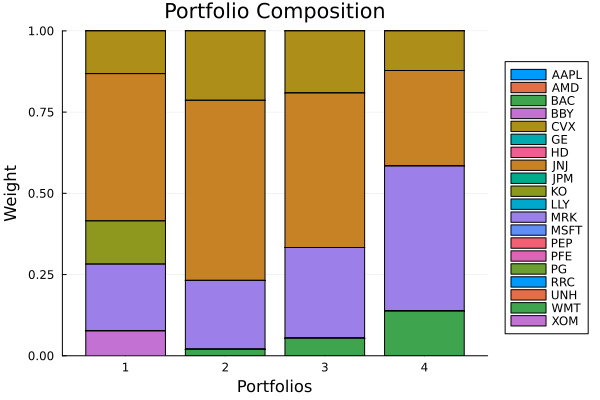

In [4]:
using StatsPlots, GraphRecipes
plot_stacked_bar_composition(results, rd)

## 3. How different is each measure from CVaR?

The sharp way to see that these are genuinely different objectives is to **cross-evaluate**:
take each minimum-risk portfolio and measure its realised risk under *every* measure. The
diagonal should be the smallest entry in its column (each portfolio is best at minimising its
own measure), and within any row the values should climb CVaR → EVaR → RLVaR → PNVaR — the
conservativeness ladder. We pass `slv` here because we are evaluating the measures standalone.

In [5]:
evals = ["CVaR" => ConditionalValueatRisk(), "EVaR" => EntropicValueatRisk(; slv = slv),
         "RLVaR" => RelativisticValueatRisk(; slv = slv),
         "PNVaR" => PowerNormValueatRisk(; slv = slv)]

cross = DataFrame(; minimises = names_r)
for (mname, m) in evals
    cross[!, Symbol(mname)] = [expected_risk(m, r.w, rd.X) for r in results]
end
pretty_table(cross; formatters = [resfmt])

┌───────────┬─────────┬─────────┬─────────┬─────────┐
│ minimises │    CVaR │    EVaR │   RLVaR │   PNVaR │
│    String │ Float64 │ Float64 │ Float64 │ Float64 │
├───────────┼─────────┼─────────┼─────────┼─────────┤
│      CVaR │ 1.764 % │ 2.062 % │ 2.218 % │ 2.476 % │
│      EVaR │  1.81 % │  1.97 % │  2.08 % │ 2.342 % │
│     RLVaR │ 1.826 % │ 1.977 % │ 2.074 % │ 2.308 % │
│     PNVaR │ 1.929 % │ 2.055 % │ 2.128 % │ 2.233 % │
└───────────┴─────────┴─────────┴─────────┴─────────┘


Reading the table: each portfolio attains the lowest value of the measure it was built to
minimise (the diagonal), confirming the four measures are not interchangeable. And every row
increases left to right — for the same portfolio, EVaR is larger than CVaR and RLVaR larger
still, because each measure puts more weight on the most extreme losses.

## 4. RLVaR as a dial: from EVaR to the worst realisation

The most useful intuition for `RelativisticValueatRisk` is that $\kappa$ slides it
continuously between two familiar measures. We hold one portfolio fixed (the CVaR-minimising
one) and evaluate RLVaR across $\kappa$, alongside EVaR and `WorstRealisation` as
the two limits.

In [6]:
w_fixed = results[1].w   ## CVaR-minimising portfolio
kappas = [0.01, 0.1, 0.3, 0.6, 0.99]
rlvar_curve = [expected_risk(RelativisticValueatRisk(; slv = slv, kappa = k), w_fixed,
                             rd.X) for k in kappas]
evar_ref = expected_risk(EntropicValueatRisk(; slv = slv), w_fixed, rd.X)
wr_ref = expected_risk(WorstRealisation(), w_fixed, rd.X)

pretty_table(DataFrame(; :kappa => kappas, :RLVaR => rlvar_curve); formatters = [resfmt])

┌─────────┬─────────┐
│   kappa │   RLVaR │
│ Float64 │ Float64 │
├─────────┼─────────┤
│    0.01 │ 2.062 % │
│     0.1 │ 2.079 % │
│     0.3 │ 2.218 % │
│     0.6 │ 2.458 % │
│    0.99 │ 2.479 % │
└─────────┴─────────┘


As $\kappa \to 0$ the RLVaR matches EVaR, and as $\kappa \to 1$ it matches the worst
realisation — the curve climbs monotonically between the two limits. That is the whole point
of RLVaR: a single coherent measure that you can tune from "tight upper bound on VaR" all the
way to "the single worst day", without ever leaving the convex world.

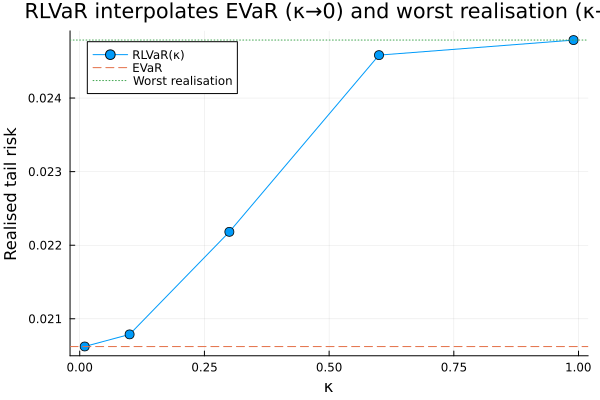

In [7]:
plot(kappas, rlvar_curve; seriestype = :path, marker = (:circle, 5), label = "RLVaR(κ)",
     xlabel = "κ", ylabel = "Realised tail risk", legend = :topleft,
     title = "RLVaR interpolates EVaR (κ→0) and worst realisation (κ→1)")
hline!([evar_ref]; label = "EVaR", linestyle = :dash)
hline!([wr_ref]; label = "Worst realisation", linestyle = :dot)

## 5. PowerNorm Value-at-Risk: the `p` dial

`PowerNormValueatRisk` plays a similar game through its power $p \ge 1$: larger `p`
pushes the measure toward the worst realisation. We evaluate it on the same fixed portfolio.

In [8]:
ps = [2.0, 4.0, 10.0]
pnvar_curve = [expected_risk(PowerNormValueatRisk(; slv = slv, p = p), w_fixed, rd.X)
               for p in ps]
pretty_table(DataFrame(; :p => ps, :PNVaR => pnvar_curve); formatters = [resfmt])

┌─────────┬─────────┐
│       p │   PNVaR │
│ Float64 │ Float64 │
├─────────┼─────────┤
│     2.0 │ 2.476 % │
│     4.0 │ 2.479 % │
│    10.0 │ 2.479 % │
└─────────┴─────────┘


PNVaR also climbs toward the worst realisation as `p` grows. We start the sweep at `p = 2`
deliberately: although the constructor permits `p = 1`, the power-cone formulation degenerates
at that boundary and the solver stalls (see the findings note in the source).

## 6. Two-sided control with `GenericValueatRiskRange`

`GenericValueatRiskRange` composes any two `XatRisk` measures into a range: a
loss-side measure on the returns plus a gain-side measure on the negated returns. This lets
you treat downside and upside *asymmetrically* — for example, an aggressive EVaR on the loss
side (punish bad tails hard) with a milder CVaR on the gain side. We compare it against the
symmetric `ConditionalValueatRiskRange`.

In [9]:
r_asym = GenericValueatRiskRange(; loss = EntropicValueatRisk(),
                                 gain = ConditionalValueatRisk())
res_asym = optimise(MeanRisk(; r = r_asym, opt = opt))
res_sym = optimise(MeanRisk(; r = ConditionalValueatRiskRange(), opt = opt))

pretty_table(DataFrame(; :assets => rd.nx, :EVaR_loss_CVaR_gain => res_asym.w,
                       :CVaR_range => res_sym.w); formatters = [resfmt])

┌────────┬─────────────────────┬────────────┐
│ assets │ EVaR_loss_CVaR_gain │ CVaR_range │
│ String │             Float64 │    Float64 │
├────────┼─────────────────────┼────────────┤
│   AAPL │               0.0 % │      0.0 % │
│    AMD │               0.0 % │      0.0 % │
│    BAC │               0.0 % │      0.0 % │
│    BBY │               0.0 % │      0.0 % │
│    CVX │               0.0 % │   10.966 % │
│     GE │             0.065 % │      0.0 % │
│     HD │               0.0 % │      0.0 % │
│    JNJ │            45.358 % │   45.582 % │
│    JPM │               0.0 % │      0.0 % │
│     KO │             0.958 % │   12.099 % │
│    LLY │               0.0 % │      0.0 % │
│    MRK │            28.527 % │   12.347 % │
│   MSFT │               0.0 % │      0.0 % │
│    PEP │               0.0 % │      0.0 % │
│    PFE │               0.0 % │      0.0 % │
│      ⋮ │                   ⋮ │          ⋮ │
└────────┴─────────────────────┴────────────┘
                               5 r

The asymmetric range tilts the portfolio toward names whose *downside* tail is well behaved,
while the symmetric CVaR range treats both sides with the same measure.

A final composition plot of the four single-sided measures from section 2 makes the family's
differences concrete: each coherent tail measure produces a recognisably different allocation.

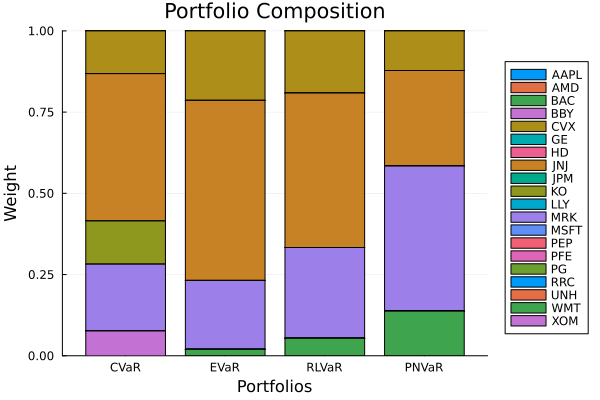

In [10]:
plot_stacked_bar_composition(results, rd; xticks = ([1, 2, 3, 4], names_r))

## Summary

Beyond CVaR, the library offers a ladder of coherent tail measures that weight the extreme
tail progressively harder:

  - `EntropicValueatRisk` is the tight coherent upper bound on VaR (exponential cone).
  - `RelativisticValueatRisk` generalises EVaR and dials continuously from EVaR
    ($\kappa \to 0$) to the worst realisation ($\kappa \to 1$) via the power cone.
  - `PowerNormValueatRisk` offers the same kind of dial through $p \ge 1$.
  - `GenericValueatRiskRange` composes any two of them into an asymmetric two-sided
    measure.

All are convex and solved by Clarabel's exponential/power cones — no special solver needed.
Reach for them when the *shape* of the extreme tail matters and CVaR's tail-averaging is too
blunt.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*